In [99]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr

from pathlib import Path
from tqdm import tqdm

# グラフの色指定
colors = ["tab:red", "tab:purple", "tab:blue", "tab:pink"]
markers = ["o", "s", "D", "P"]

# グラフ全体のフォント設定
# plt.rcParams['font.family'] = 'serif'  # 全体のフォントをSerifに設定
# plt.rcParams['mathtext.fontset'] = 'cm'  # 数式のフォントをComputer Modernに設定
# plt.rcParams['mathtext.rm'] = 'serif'  # TeXの通常フォントをSerifに設定
# plt.rcParams['font.size'] = 18  # デフォルトフォントサイズ
# plt.rcParams['axes.labelsize'] = 18  # 軸ラベルのフォントサイズ
# plt.rcParams['axes.titlesize'] = 22  # タイトルのフォントサイズ
# plt.rcParams['legend.fontsize'] = 16  # 凡例のフォントサイズ
# plt.rcParams['grid.color'] = 'gray'  # グリッドの色を薄い灰色に設定
# plt.rcParams['grid.linestyle'] = ':'  # グリッドを点線に設定
# plt.rcParams['grid.linewidth'] = 0.5  # グリッドの線幅を設定

In [100]:
network_type_list = ["M1"]
N_list = [320, 1429]
z = 6
z_bar = 6
cmin = 1.00
file_type = "final"
ini_type = "nonbfs"
index_cols = [] if file_type == "final" else ["time"]
index_cols.extend(["itr", "lambda", "mu", "rho", "c"])

In [103]:
sim_results=[]
N = 1429
network_type = "M1"
sim_path = os.path.abspath(os.path.join('..',f'java-project/output/sis/{network_type}/z={z}/N={N}cMin={cmin:.2f}{file_type}{ini_type}'))
print(os.path.relpath(sim_path))
for path in Path(sim_path).glob('**/results_*.csv'):
    sim_results.append(pd.read_csv(path))
sim_results = pd.concat(sim_results, ignore_index=True)
sim_results = xr.Dataset.from_dataframe(sim_results.set_index(index_cols))

../java-project/output/sis/M1/z=6/N=1429cMin=1.00finalnonbfs


In [107]:
rho0_values = sim_results["rho"].values
c_values = sim_results["c"].values
print(rho0_values)

[0.001 0.1   1.   ]


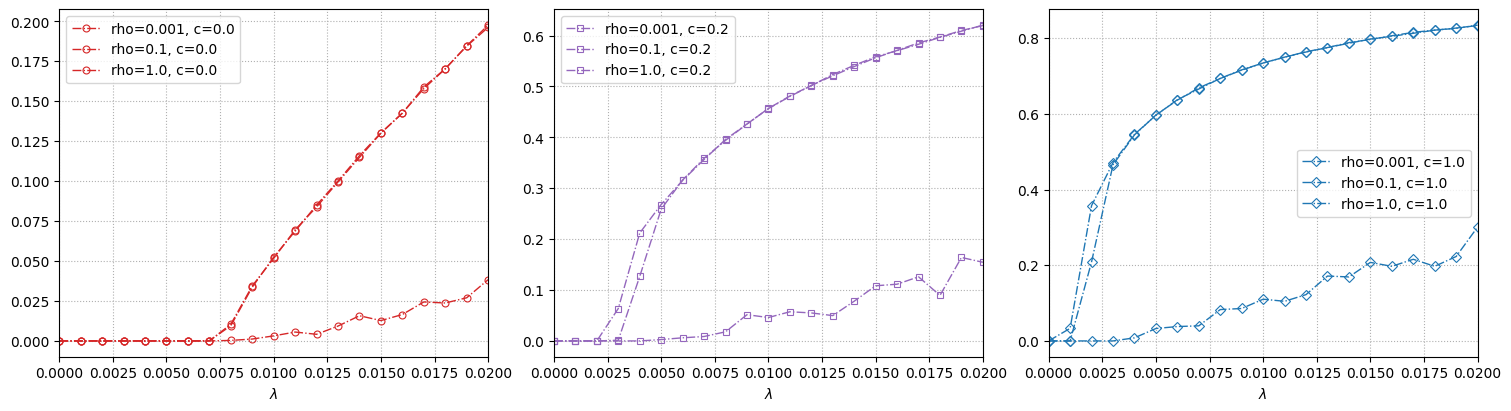

In [110]:
fig, axs = plt.subplots(1, len(c_values), figsize=(5*len(c_values), 4), constrained_layout=True)
if len(c_values) == 1:
    axs = [axs]
for cidx, c in enumerate(c_values):
    for ridx, rho in enumerate(rho0_values):
        I = sim_results["I"]
        I_rho_c = I.sel(c=c).sel(rho=rho).mean(dim="itr")/1429
        axs[cidx].plot(I["lambda"].values, I_rho_c, marker=markers[cidx], linewidth=1.0, markersize=5, markerfacecolor="none",ls="-.", markeredgewidth=0.8, color=colors[cidx], label=f"rho={rho}, c={c}")
    min_lambda = I["lambda"].min()
    max_lambda = I["lambda"].max()
    axs[cidx].set_xlim(min_lambda, max_lambda)
    axs[cidx].grid(True, linestyle=":")
    axs[cidx].set_xlabel(r"$\lambda$")
    if cidx == 0:
        axs[ridx].set_ylabel("I")
    else:
        axs[ridx].set_ylabel("")
    # axs[cidx].set_xlim(0, 0.02)
    axs[cidx].legend()
plt.show()


/Users/black/trend-sar/network-data/M1.csv/edges.csv
N: 1428
k_max: 339


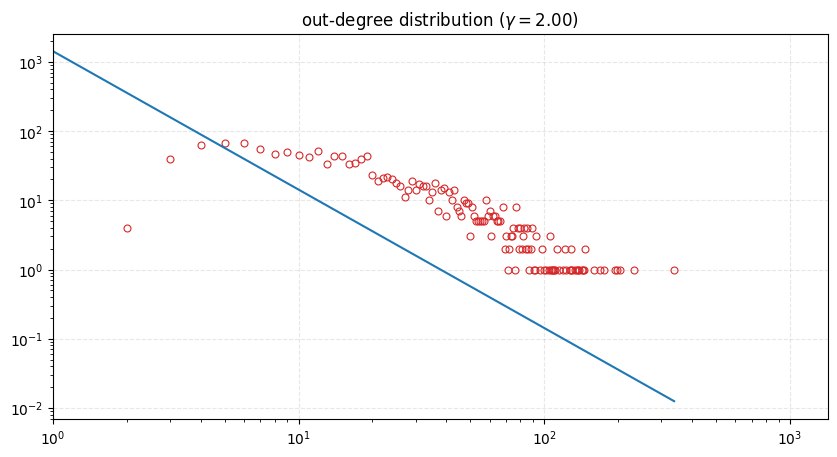

In [ ]:
import networkx as nx

network_path = os.path.abspath(os.path.join("..", "network-data", "M1.csv", "edges.csv"))
print(network_path)
G = nx.read_edgelist(network_path, delimiter=",", nodetype=int)

deg = np.array([d for _, d in G.degree()])
k_val = np.arange(1, deg.max())
print(f"N: {max(G.nodes())}")
print(f"k_max: {deg.max()}")

distribution = np.bincount(deg)
distribution = distribution

gamma = 2.0
y = k_val **(-gamma) * G.number_of_nodes()

fig, ax = plt.subplots(1, 1, figsize=(10, 5))

ax.plot(distribution, ls="", marker="o", markersize=5, markerfacecolor="none", markeredgewidth=0.8, color="tab:red")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_title(rf"out-degree distribution ($\gamma={gamma:.2f}$)")
ax.plot(k_val, y, label=r"$y=k^{-\gamma}$")
ax.set_xlim(1, G.number_of_nodes())
ax.grid(True, alpha=0.3, ls="--")
# ax.legend()
plt.show()